# Name : Muhammad Danish Zaheer Awan
# REG id : 25280092
## Task 2 - Unsupervised Domain Adaptation

## Imports and project setup

In [1]:
# Import standard utilities for paths, memory cleanup, tables, and plotting.
# Locate the repository root so imports work from either notebook location.
import gc
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import torch
from IPython.display import display

In [2]:
working_directory = Path.cwd().resolve()
project_root = next(
    (path for path in (working_directory, *working_directory.parents)
     if (path / 'task2').is_dir() and (path / 'Data').is_dir()),
    None,
)
if project_root is None:
    raise RuntimeError('Run this notebook from inside the PA_1 project.')
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

In [3]:
# Import configuration helpers and the shared PACS dataset protocol.
# These modules keep paths, source splits, and target-label access controlled.

from shared_task_2and3.pacs_protocol import build_task2_datasets, prepare_pacs_protocol
from task2.configs.config_loader import (
    create_output_directories,
    get_output_paths,
    load_config,
)

In [4]:
# Import the common trainer and final evaluation safety functions.
# Target labels remain inaccessible until the explicit locked-evaluation cell.

from task2.evaluation.evaluate_final import (
    create_experiment_lock,
    run_final_evaluation,
)
from task2.evaluation.metrics import save_json
from task2.training.train import (
    select_training_device,
    set_random_seed,
    train_or_load_task2_method,
)

## Runtime and configurations

In [5]:
# Define the reproducible runtime setup and prefer the available CUDA GPU.
# The same seed is restored before every method is initialized and trained.

def configure_runtime(seed=6304):
    set_random_seed(seed)
    return select_training_device()

In [6]:
# Initialize the runtime and print the selected PyTorch compute environment.
# CUDA will be used for training and feature extraction when it is available.

DEVICE = configure_runtime()
print(f'Project root: {project_root}')
print(f'PyTorch: {torch.__version__}')
print(f'Device: {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')

Project root: C:\Users\DanishZaheer\Desktop\LUMS\Semester_3\ATML\PA_1
PyTorch: 2.11.0+cu128
Device: cuda
GPU: NVIDIA GeForce RTX 3060 Laptop GPU


In [7]:
# Define one helper that loads all four fixed main experiment configurations.
# Common settings come from base.yaml and method settings come from each override.

def load_main_configurations():
    return {
        method_name: load_config(method_name)
        for method_name in ('source_only', 'dan', 'dann', 'cdan')
    }

In [8]:
# Load the merged configurations and create the data-cache and results folders.
# Display only method-specific values so accidental differences are easy to inspect.

MAIN_CONFIGURATIONS = load_main_configurations()
OUTPUT_PATHS = create_output_directories(MAIN_CONFIGURATIONS['source_only'])
display(pd.DataFrame([config['method'] for config in MAIN_CONFIGURATIONS.values()]))

,name,run_name,mmd_weight,kernel_bandwidth_multipliers,domain_loss_weight,discriminator_hidden_dimension,discriminator_dropout,grl_maximum_strength,discriminator_input_dimension
0,source_only,source_only,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,dan,dan,1.0,"[0.5, 1.0, 2.0]",NaN,NaN,NaN,NaN,NaN
2,dann,dann,NaN,NaN,1.0,256.0,0.5,1.0,NaN
3,cdan,cdan,NaN,NaN,1.0,256.0,0.5,1.0,3584.0


## PACS download and shared protocol

In [9]:
# Define dataset preparation using paths stored in the common configuration.
# PACS is downloaded under Data and its protocol is saved in shared_task_2and3.

def prepare_task2_data(configuration, download=True, overwrite_split=False):
    paths = get_output_paths(configuration)
    return prepare_pacs_protocol(
        dataset_directory=paths['dataset_directory'],
        download_directory=paths['download_directory'],
        split_file=paths['split_file'],
        download=download,
        overwrite=overwrite_split,
        require_official_counts=configuration['dataset']['require_official_counts'],
    )

In [10]:
# Download or reuse PACS and create or validate the seed-6304 source splits.
# This stage never returns target class labels to the notebook.

PACS_IMAGE_ROOT, PACS_PROTOCOL = prepare_task2_data(
    MAIN_CONFIGURATIONS['source_only'],
    download=True,
    overwrite_split=False,
)

PACS image root: C:\Users\DanishZaheer\Desktop\LUMS\Semester_3\ATML\PA_1\Data\pacs
PACS domain counts: {'photo': 1670, 'art_painting': 2048, 'cartoon': 2344, 'sketch': 3929}
Using the existing shared PACS protocol.
Saved PACS protocol: C:\Users\DanishZaheer\Desktop\LUMS\Semester_3\ATML\PA_1\shared_task_2and3\splits\pacs_sketch_seed6304.json


In [11]:
# Define a compact table summarizing each saved source-domain split.
# The counts verify the independent stratified 80/20 protocol before training.

def create_protocol_summary(protocol):
    rows = []
    for domain, split in protocol['source_splits'].items():
        rows.append({
            'domain': domain,
            'train_images': len(split['train_identifiers']),
            'validation_images': len(split['validation_identifiers']),
        })
    rows.append({
        'domain': protocol['target_domain'] + ' (unlabeled adaptation)',
        'train_images': protocol['target_adaptation']['count'],
        'validation_images': 0,
    })
    return pd.DataFrame(rows)

In [12]:
# Display the saved source and unlabeled target counts for manual verification.
# Confirm that the protocol explicitly records labels_exposed as false for Sketch.

display(create_protocol_summary(PACS_PROTOCOL))
print('Target labels exposed:', PACS_PROTOCOL['target_adaptation']['labels_exposed'])

,domain,train_images,validation_images
0,photo,1336,334
1,art_painting,1638,410
2,cartoon,1875,469
3,sketch (unlabeled adaptation),3929,0


Target labels exposed: False


In [13]:
# Define dataset construction with random source/target training transforms.
# The target evaluation dataset is deliberately not constructed at this stage.

def create_unlabeled_adaptation_datasets(image_root, protocol, configuration):
    transform_config = configuration['transforms']
    return build_task2_datasets(
        image_root,
        protocol,
        resize_size=transform_config['resize_size'],
        crop_size=transform_config['crop_size'],
        include_target_labels=False,
    )

In [14]:
# Construct the three labeled source datasets and the unlabeled Sketch datasets.
# Assert that no final labeled target dataset exists before training begins.

TASK2_DATASETS = create_unlabeled_adaptation_datasets(
    PACS_IMAGE_ROOT,
    PACS_PROTOCOL,
    MAIN_CONFIGURATIONS['source_only'],
)
assert 'target_evaluation' not in TASK2_DATASETS

In [15]:
# Define a dataset-size table for the source train, source validation, and target sets.
# This provides a final sampling check before any expensive GPU training.

def create_dataset_size_table(datasets):
    rows = []
    for domain, dataset in datasets['source_train'].items():
        rows.append({'domain': domain, 'split': 'train', 'size': len(dataset)})
    for domain, dataset in datasets['source_validation'].items():
        rows.append({'domain': domain, 'split': 'validation', 'size': len(dataset)})
    rows.append({
        'domain': 'sketch',
        'split': 'unlabeled adaptation',
        'size': len(datasets['target_adaptation']),
    })
    return pd.DataFrame(rows)

In [16]:
# Display every dataset size and inspect one unlabeled target sample safely.
# The assertion verifies that the adaptation sample contains no label key.

display(create_dataset_size_table(TASK2_DATASETS))
target_sample = TASK2_DATASETS['target_adaptation'][0]
assert 'label' not in target_sample
print(target_sample['identifier'], target_sample['image'].shape)

,domain,split,size
0,photo,train,1336
1,art_painting,train,1638
2,cartoon,train,1875
3,photo,validation,334
4,art_painting,validation,410
5,cartoon,validation,469
6,sketch,unlabeled adaptation,3929


sketch_70e617fb825e778c torch.Size([3, 224, 224])


## Common training helper

In [17]:
# Define one wrapper that trains or reloads a source-selected method checkpoint.
# Release model tensors afterward so sequential experiments fit comfortably on the GPU.

def train_and_release(configuration, datasets, force_retrain=False):
    result = train_or_load_task2_method(
        configuration,
        datasets,
        device=DEVICE,
        force_retrain=force_retrain,
    )
    compact_result = {
        'checkpoint_file': result['checkpoint_file'],
        'history_file': result['history_file'],
        'history': result['history'],
        'selected_epoch': result['checkpoint']['epoch'],
        'selection_value': result['checkpoint']['selection_value'],
    }
    result['model'].to('cpu')
    if result['discriminator'] is not None:
        result['discriminator'].to('cpu')
    del result
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    return compact_result

In [18]:
# Retrain every method once with the new shared FP32 and gradient-clipping setup.
# Change this back to False after all stable checkpoints have been regenerated.
FORCE_RETRAIN = False 
TRAINING_RESULTS = {}

## 1. Source-only ERM

In [19]:
# Train Source-only ERM using balanced labeled batches from the three sources.
# This run never creates a target loader and becomes the unchanged Task 3 baseline.

TRAINING_RESULTS['source_only'] = train_and_release(
    MAIN_CONFIGURATIONS['source_only'],
    TASK2_DATASETS,
    force_retrain=FORCE_RETRAIN,
)
display(TRAINING_RESULTS['source_only']['history'].tail())

Backbone: ResNet-18 (IMAGENET1K_V1)
Feature dimension: 512
Trainable backbone parameters: 11,176,512/11,176,512
Complete classifier parameters: 11,180,103/11,180,103
Loaded checkpoint: C:\Users\DanishZaheer\Desktop\LUMS\Semester_3\ATML\PA_1\task2\results\checkpoints\source_only_best.pt


,epoch,total_loss,classification_loss,alignment_loss,domain_loss,domain_accuracy,grl_strength,gradient_norm_before_clipping,photo_validation_accuracy,photo_validation_macro_f1,art_painting_validation_accuracy,art_painting_validation_macro_f1,cartoon_validation_accuracy,cartoon_validation_macro_f1,mean_source_validation_accuracy,mean_source_validation_macro_f1
10,11,0.049724,0.049724,0.0,0.0,0.0,0.0,5.169283,0.961078,0.952663,0.858537,0.857066,0.938166,0.940676,0.919260,0.916802
11,12,0.048340,0.048340,0.0,0.0,0.0,0.0,4.801525,0.970060,0.966602,0.904878,0.900416,0.953092,0.958104,0.942677,0.941707
12,13,0.052823,0.052823,0.0,0.0,0.0,0.0,5.623826,0.964072,0.957758,0.865854,0.861801,0.923241,0.923245,0.917722,0.914268
13,14,0.041879,0.041879,0.0,0.0,0.0,0.0,4.278371,0.949102,0.940402,0.875610,0.869398,0.948827,0.953829,0.924513,0.921210
14,15,0.052516,0.052516,0.0,0.0,0.0,0.0,5.427554,0.958084,0.948907,0.875610,0.872187,0.942431,0.945878,0.925375,0.922324


## 2. DAN

In [20]:
# Train DAN with unit-weight multi-kernel MMD on 512-dimensional features.
# Sketch images contribute only to the alignment term and never to classification.

TRAINING_RESULTS['dan'] = train_and_release(
    MAIN_CONFIGURATIONS['dan'],
    TASK2_DATASETS,
    force_retrain=FORCE_RETRAIN,
)

display(TRAINING_RESULTS['dan']['history'].tail())

Backbone: ResNet-18 (IMAGENET1K_V1)
Feature dimension: 512
Trainable backbone parameters: 11,176,512/11,176,512
Complete classifier parameters: 11,180,103/11,180,103
Loaded checkpoint: C:\Users\DanishZaheer\Desktop\LUMS\Semester_3\ATML\PA_1\task2\results\checkpoints\dan_best.pt


,epoch,total_loss,classification_loss,alignment_loss,domain_loss,domain_accuracy,grl_strength,gradient_norm_before_clipping,photo_validation_accuracy,photo_validation_macro_f1,art_painting_validation_accuracy,art_painting_validation_macro_f1,cartoon_validation_accuracy,cartoon_validation_macro_f1,mean_source_validation_accuracy,mean_source_validation_macro_f1
1,2,2.080225,1.874186,0.206039,0.0,0.0,0.0,104.924763,0.167665,0.041026,0.143902,0.035943,0.123667,0.031445,0.145078,0.036138
2,3,2.120903,1.940822,0.180081,0.0,0.0,0.0,140.629079,0.167665,0.041026,0.143902,0.035943,0.123667,0.031445,0.145078,0.036138
3,4,2.050843,1.937772,0.113071,0.0,0.0,0.0,147.164181,0.257485,0.058503,0.219512,0.051429,0.172708,0.042078,0.216568,0.050670
4,5,2.028158,1.929639,0.098518,0.0,0.0,0.0,80.971868,0.257485,0.058503,0.219512,0.051429,0.172708,0.042078,0.216568,0.050670
5,6,1.977092,1.926468,0.050624,0.0,0.0,0.0,81.704072,0.257485,0.058503,0.219512,0.051429,0.172708,0.042078,0.216568,0.050670


## 3. DANN

In [21]:
# Train DANN with scheduled gradient reversal and marginal domain prediction.
# Classification uses sources while the binary domain loss uses source and target.

TRAINING_RESULTS['dann'] = train_and_release(
    MAIN_CONFIGURATIONS['dann'],
    TASK2_DATASETS,
    force_retrain=FORCE_RETRAIN,
)
display(TRAINING_RESULTS['dann']['history'].tail())

Backbone: ResNet-18 (IMAGENET1K_V1)
Feature dimension: 512
Trainable backbone parameters: 11,176,512/11,176,512
Complete classifier parameters: 11,180,103/11,180,103
Loaded checkpoint: C:\Users\DanishZaheer\Desktop\LUMS\Semester_3\ATML\PA_1\task2\results\checkpoints\dann_best.pt


,epoch,total_loss,classification_loss,alignment_loss,domain_loss,domain_accuracy,grl_strength,gradient_norm_before_clipping,photo_validation_accuracy,photo_validation_macro_f1,art_painting_validation_accuracy,art_painting_validation_macro_f1,cartoon_validation_accuracy,cartoon_validation_macro_f1,mean_source_validation_accuracy,mean_source_validation_macro_f1
4,5,2422.171153,685.094313,1737.076832,1737.076832,0.531826,0.634124,4.429300e+05,0.395210,0.213917,0.224390,0.142189,0.211087,0.169592,0.276896,0.175232
5,6,7763.935697,2813.473379,4950.462362,4950.462362,0.521277,0.723413,2.912719e+06,0.257485,0.058503,0.219512,0.051429,0.172708,0.042078,0.216568,0.050670
6,7,280.680585,98.052675,182.627910,182.627910,0.491223,0.793679,1.279078e+05,0.110778,0.028494,0.090244,0.023650,0.057569,0.015553,0.086197,0.022566
7,8,257.063033,134.629831,122.433202,122.433202,0.500089,0.847683,2.921991e+05,0.104790,0.032615,0.090244,0.035741,0.098081,0.049583,0.097705,0.039313
8,9,25.638690,24.232334,1.406355,1.406355,0.507270,0.888437,6.060536e+04,0.173653,0.111549,0.185366,0.068748,0.179104,0.090851,0.179374,0.090383


## 4. CDAN

In [22]:
# Train CDAN using the attached feature-probability outer-product representation.
# Its 3584-dimensional discriminator otherwise matches the DANN architecture.

TRAINING_RESULTS['cdan'] = train_and_release(
    MAIN_CONFIGURATIONS['cdan'],
    TASK2_DATASETS,
    force_retrain=FORCE_RETRAIN,
)
display(TRAINING_RESULTS['cdan']['history'].tail())

Backbone: ResNet-18 (IMAGENET1K_V1)
Feature dimension: 512
Trainable backbone parameters: 11,176,512/11,176,512
Complete classifier parameters: 11,180,103/11,180,103
Loaded checkpoint: C:\Users\DanishZaheer\Desktop\LUMS\Semester_3\ATML\PA_1\task2\results\checkpoints\cdan_best.pt


,epoch,total_loss,classification_loss,alignment_loss,domain_loss,domain_accuracy,grl_strength,gradient_norm_before_clipping,photo_validation_accuracy,photo_validation_macro_f1,art_painting_validation_accuracy,art_painting_validation_macro_f1,cartoon_validation_accuracy,cartoon_validation_macro_f1,mean_source_validation_accuracy,mean_source_validation_macro_f1
5,6,0.861455,0.161394,0.700061,0.700061,0.584574,0.723413,14.280544,0.949102,0.942247,0.890244,0.884334,0.914712,0.923751,0.918019,0.916777
6,7,0.837417,0.135665,0.701752,0.701752,0.562766,0.793679,15.839046,0.934132,0.923949,0.868293,0.862106,0.936034,0.942439,0.912820,0.909498
7,8,1.264509,0.367900,0.896610,0.896610,0.580231,0.847683,74.961561,0.952096,0.942771,0.865854,0.867693,0.886994,0.901748,0.901648,0.904071
8,9,0.829562,0.135270,0.694292,0.694292,0.558067,0.888437,14.642479,0.790419,0.832127,0.875610,0.874012,0.931770,0.936547,0.865933,0.880895
9,10,1.244548,0.346111,0.898437,0.898437,0.545656,0.918770,93.951378,0.946108,0.938335,0.860976,0.856275,0.916844,0.920995,0.907976,0.905202


## 5. Training curves and source-selected checkpoints

In [23]:
# Define a 4-by-3 grid so every method has its own readable row of curves.
# Show classification loss, alignment loss, and validation macro-F1 separately.

def plot_training_curves(training_results, output_file):
    method_order = ['source_only', 'dan', 'dann', 'cdan']
    method_colors = {
        'source_only': 'tab:blue',
        'dan': 'tab:orange',
        'dann': 'tab:green',
        'cdan': 'tab:red',
    }
    metric_columns = [
        ('classification_loss', 'Source classification loss', 'Loss'),
        ('alignment_loss', 'Alignment or domain loss', 'Loss'),
        ('mean_source_validation_macro_f1', 'Mean source validation macro-F1', 'Macro-F1'),
    ]
    figure, axes = plt.subplots(4, 3, figsize=(18, 18), squeeze=False)

    for row_index, method_name in enumerate(method_order):
        result = training_results[method_name]
        history = result['history']
        selected_epoch = result['selected_epoch']
        for column_index, (metric_name, metric_title, y_label) in enumerate(metric_columns):
            axis = axes[row_index, column_index]
            axis.plot(
                history['epoch'],
                history[metric_name],
                color=method_colors[method_name],
                linewidth=2,
            )
            axis.axvline(
                selected_epoch,
                color='black',
                linestyle='--',
                alpha=0.55,
            )
            axis.set(
                title=f'{method_name.upper()} - {metric_title}',
                xlabel='Epoch',
                ylabel=y_label,
            )
            if metric_name == 'mean_source_validation_macro_f1':
                axis.set_ylim(0.0, 1.0)
            axis.grid(alpha=0.3)

    figure.suptitle(
        'Task 2 training curves (dashed line = selected checkpoint)',
        fontsize=16,
        y=1.01,
    )
    figure.tight_layout()
    figure.savefig(output_file, dpi=200, bbox_inches='tight')
    return figure

Saved: C:\Users\DanishZaheer\Desktop\LUMS\Semester_3\ATML\PA_1\task2\results\figures\main_training_curves.png


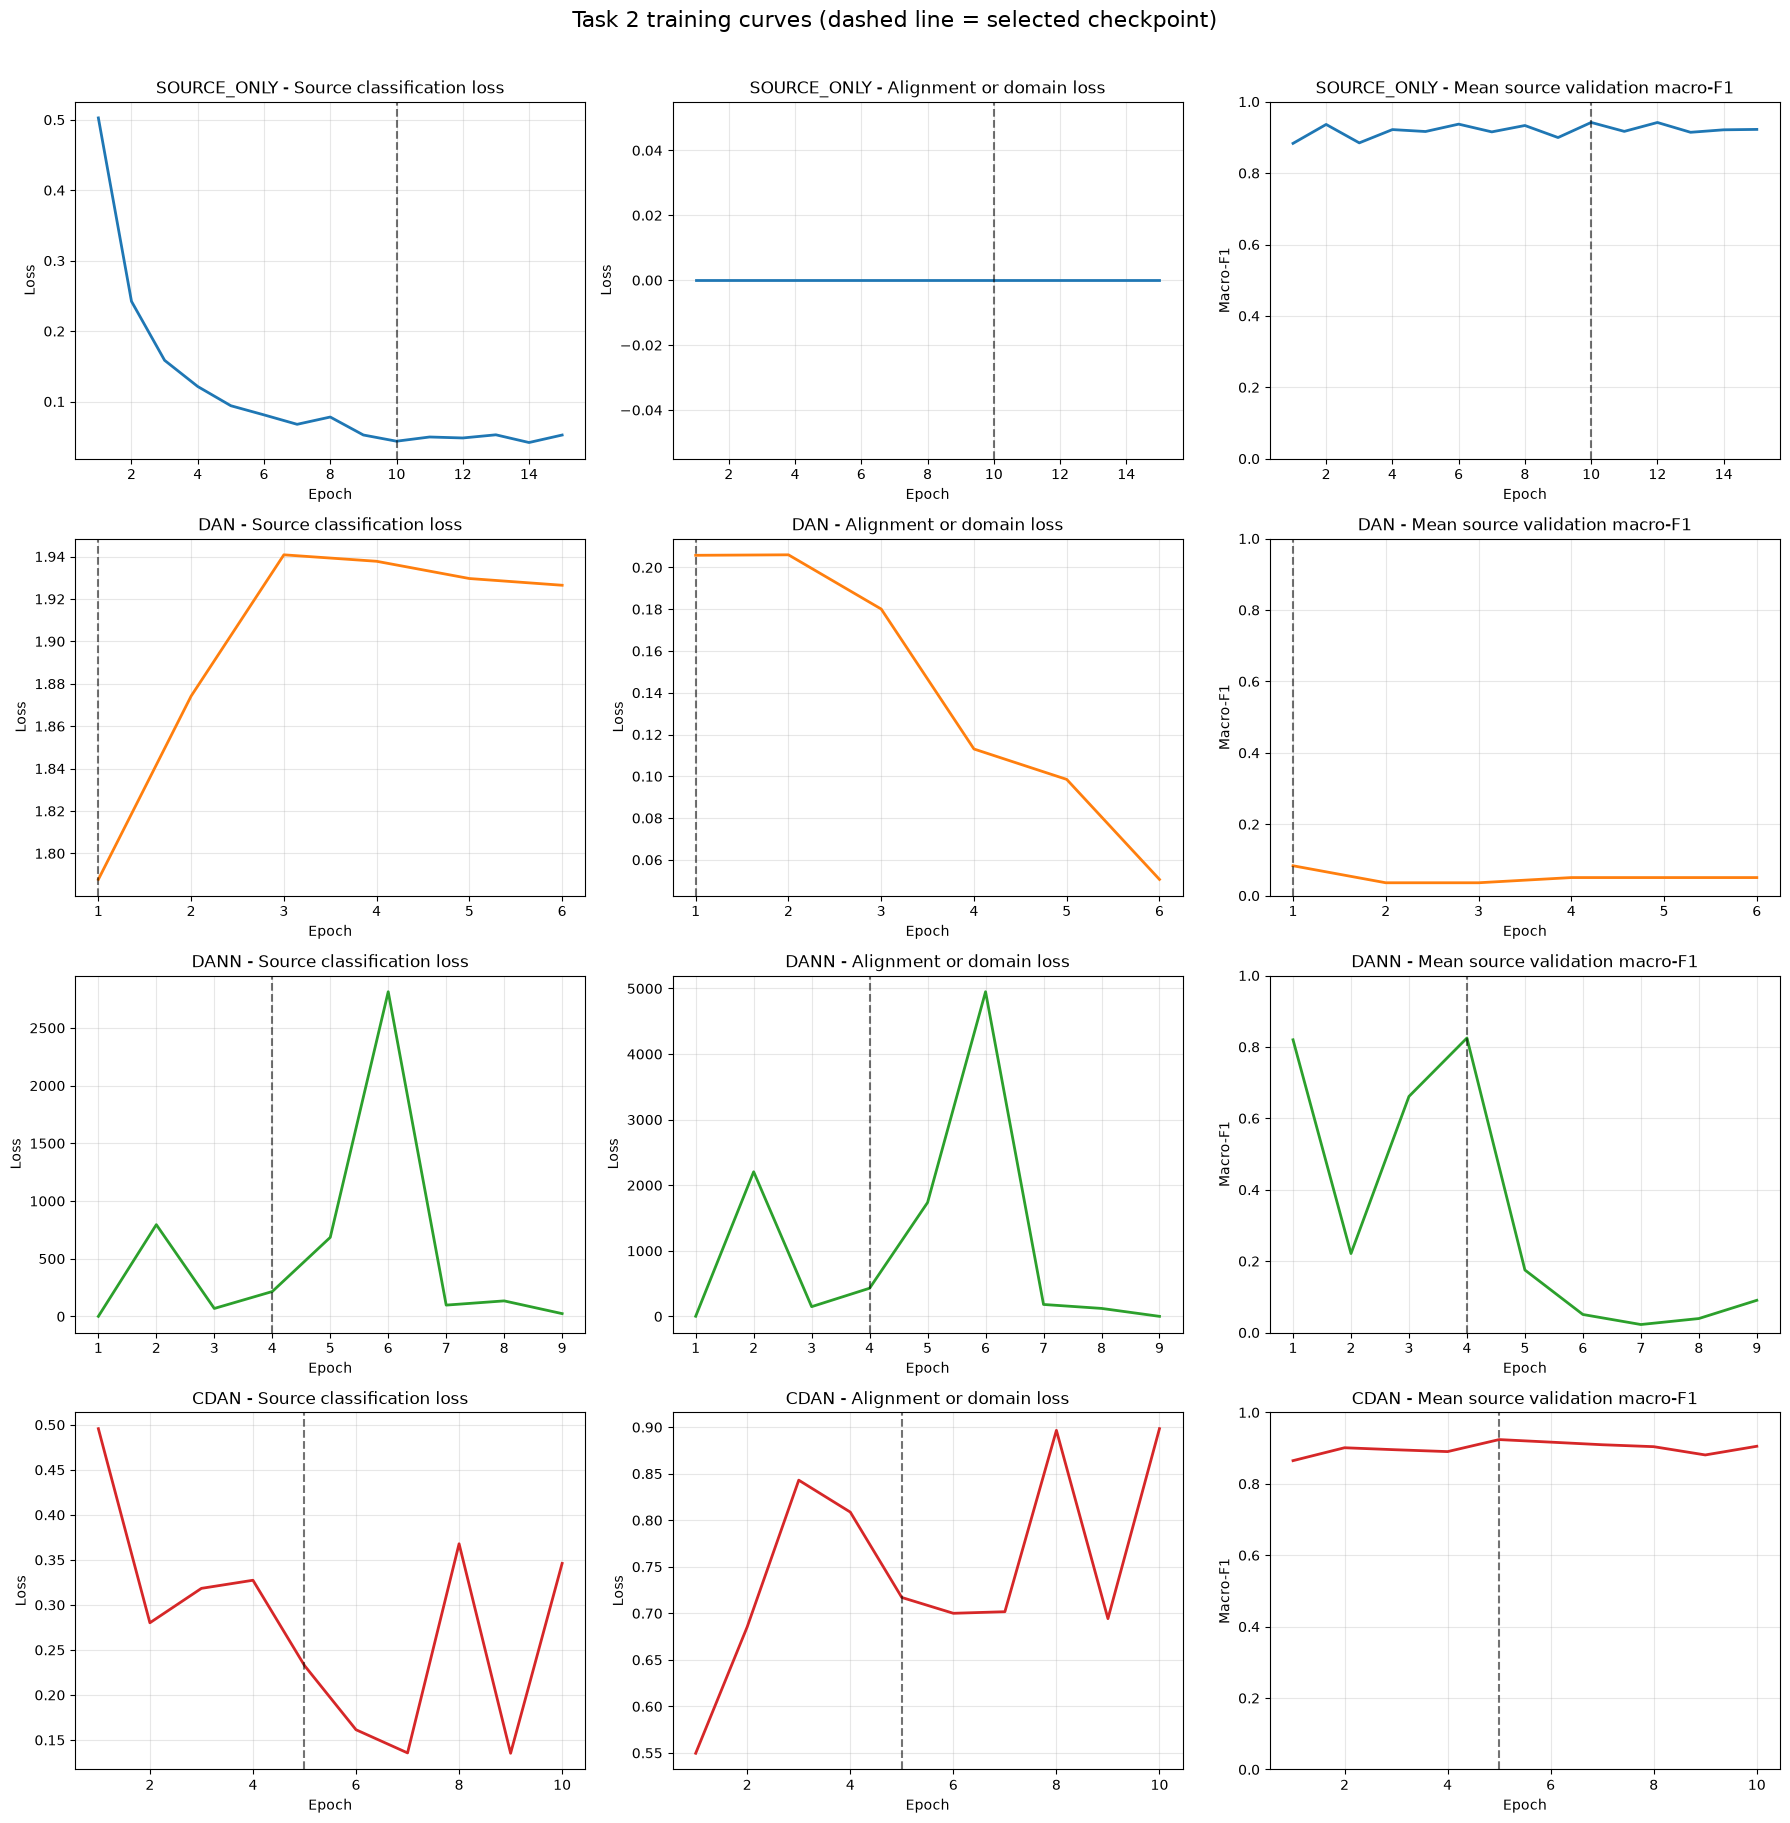

In [24]:
# Plot and save the four main training histories before viewing target results.
# These curves use only training losses and labeled source-validation performance.

MAIN_CURVE_FILE = OUTPUT_PATHS['figures_directory'] / 'main_training_curves.png'
plot_training_curves(TRAINING_RESULTS, MAIN_CURVE_FILE)
print(f'Saved: {MAIN_CURVE_FILE}')

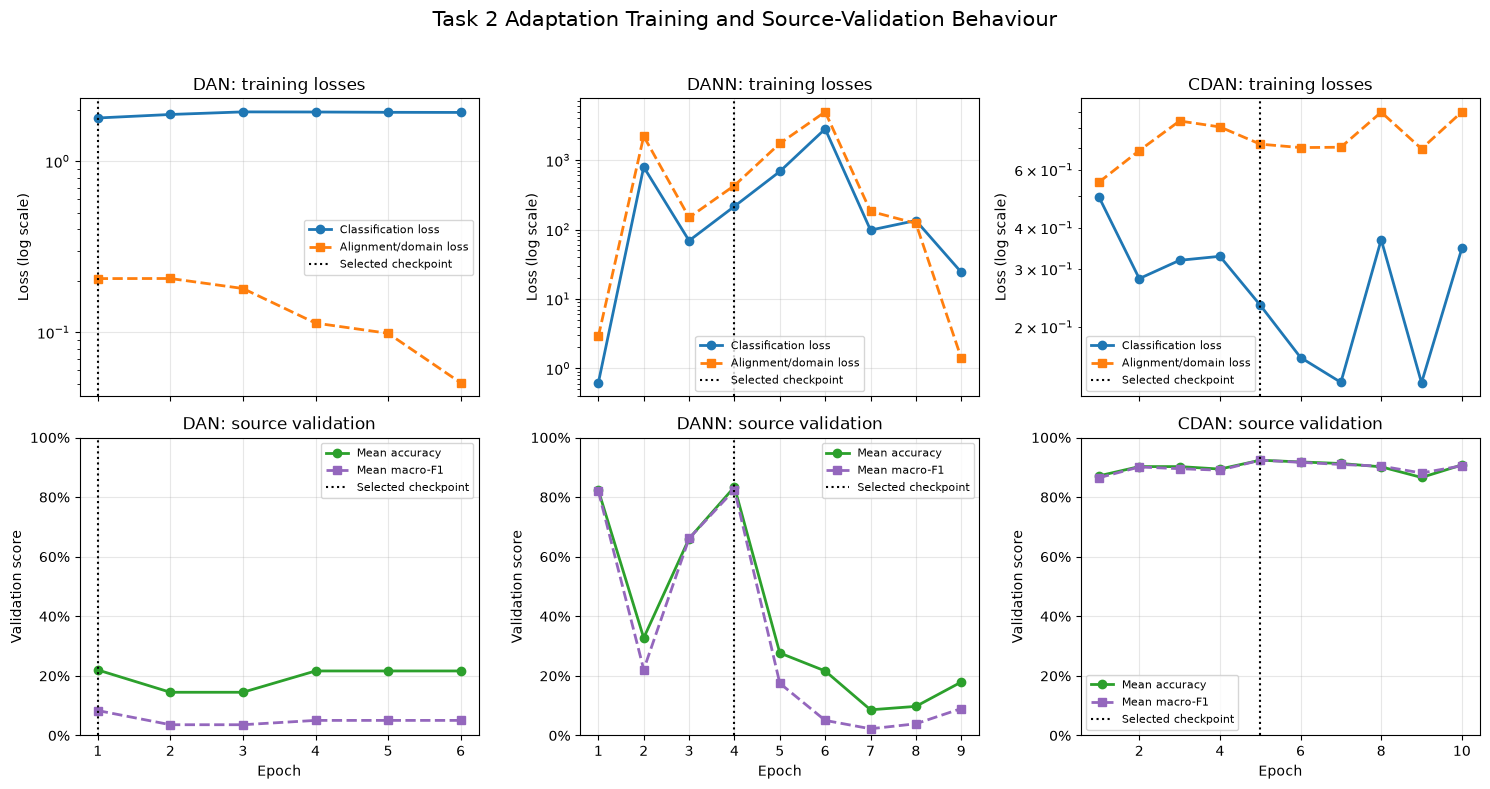

Saved: C:\Users\DanishZaheer\Desktop\LUMS\Semester_3\ATML\PA_1\task2\results\figures\report_training_curves_2x3.png


In [48]:
# Create a compact 2-by-3 report figure for DAN, DANN, and CDAN training.
# The first row shows training objectives; the second shows source-validation performance.

from matplotlib.ticker import PercentFormatter

report_methods = [
    ('dan', 'DAN'),
    ('dann', 'DANN'),
    ('cdan', 'CDAN'),
]

figure, axes = plt.subplots(
    2,
    3,
    figsize=(15, 8),
    sharex='col',
)

for column_index, (method_name, display_name) in enumerate(report_methods):
    result = TRAINING_RESULTS[method_name]
    history = result['history']
    selected_epoch = result['selected_epoch']

    loss_axis = axes[0, column_index]
    metric_axis = axes[1, column_index]

    # Plot source classification and alignment/domain losses separately.
    loss_axis.plot(
        history['epoch'],
        history['classification_loss'],
        marker='o',
        linewidth=2,
        label='Classification loss',
        color='tab:blue',
    )
    loss_axis.plot(
        history['epoch'],
        history['alignment_loss'],
        marker='s',
        linestyle='--',
        linewidth=2,
        label='Alignment/domain loss',
        color='tab:orange',
    )
    loss_axis.axvline(
        selected_epoch,
        color='black',
        linestyle=':',
        linewidth=1.5,
        label='Selected checkpoint',
    )
    loss_axis.set_title(f'{display_name}: training losses')
    loss_axis.set_ylabel('Loss (log scale)')
    loss_axis.set_yscale('log')
    loss_axis.grid(alpha=0.3)
    loss_axis.legend(fontsize=8)

    # Plot mean source-validation accuracy and macro-F1.
    metric_axis.plot(
        history['epoch'],
        history['mean_source_validation_accuracy'],
        marker='o',
        linewidth=2,
        label='Mean accuracy',
        color='tab:green',
    )
    metric_axis.plot(
        history['epoch'],
        history['mean_source_validation_macro_f1'],
        marker='s',
        linestyle='--',
        linewidth=2,
        label='Mean macro-F1',
        color='tab:purple',
    )
    metric_axis.axvline(
        selected_epoch,
        color='black',
        linestyle=':',
        linewidth=1.5,
        label='Selected checkpoint',
    )
    metric_axis.set_title(f'{display_name}: source validation')
    metric_axis.set_xlabel('Epoch')
    metric_axis.set_ylabel('Validation score')
    metric_axis.set_ylim(0.0, 1.0)
    metric_axis.yaxis.set_major_formatter(PercentFormatter(1.0))
    metric_axis.grid(alpha=0.3)
    metric_axis.legend(fontsize=8)

figure.suptitle(
    'Task 2 Adaptation Training and Source-Validation Behaviour',
    fontsize=15,
)

figure.tight_layout(rect=[0, 0, 1, 0.96])

REPORT_CURVE_FILE = (
    OUTPUT_PATHS['figures_directory']
    / 'report_training_curves_2x3.png'
)
figure.savefig(
    REPORT_CURVE_FILE,
    dpi=300,
    bbox_inches='tight',
)

plt.show()
print(f'Saved: {REPORT_CURVE_FILE}')

In [25]:
# Define a table showing the selected epoch and best source macro-F1 per run.
# This confirms checkpoint selection did not consult any target class labels.

def create_checkpoint_selection_table(training_results):
    return pd.DataFrame([
        {
            'result_name': result_name,
            'selected_epoch': result['selected_epoch'],
            'mean_source_validation_macro_f1': result['selection_value'],
            'checkpoint_file': str(result['checkpoint_file']),
        }
        for result_name, result in training_results.items()
    ])

In [26]:
# Display the source-only selection evidence for every completed main experiment.
# Keep this table with the saved histories when checking reproducibility.

display(create_checkpoint_selection_table(TRAINING_RESULTS))

,result_name,selected_epoch,mean_source_validation_macro_f1,checkpoint_file
0,source_only,10,0.941818,C:\Users\DanishZaheer\Desktop\LUMS\Semester_3\...
1,dan,1,0.083759,C:\Users\DanishZaheer\Desktop\LUMS\Semester_3\...
2,dann,4,0.824918,C:\Users\DanishZaheer\Desktop\LUMS\Semester_3\...
3,cdan,5,0.923941,C:\Users\DanishZaheer\Desktop\LUMS\Semester_3\...


## 5. Controlled DAN alignment-strength study

In [27]:
# Record student-written expectations before evaluating controlled-study targets.
# Replace every TODO without using Sketch-label metrics to change the tested settings.

HYPOTHESES = {
    'main_methods': 'no hypothesis',
}
save_json(HYPOTHESES, OUTPUT_PATHS['metrics_directory'] / 'task2_hypotheses.json')
display(HYPOTHESES)

{'main_methods': 'no hypothesis'}

In [28]:
# Define the two additional DAN configurations needed around the main weight of 1.
# Unique run names keep their checkpoints and histories separate from main DAN.

def build_dan_design_configurations():
    return {
        'dan_lambda_0p1': load_config('dan', overrides={
            'method': {'run_name': 'dan_lambda_0p1', 'mmd_weight': 0.1}
        }),
        'dan_lambda_10': load_config('dan', overrides={
            'method': {'run_name': 'dan_lambda_10', 'mmd_weight': 10.0}
        }),
    }

In [29]:
# Create and display the bounded DAN configurations before running the study.
# The existing main DAN run supplies the required middle setting lambda equal to 1.

DESIGN_CONFIGURATIONS = build_dan_design_configurations()
display(pd.DataFrame([
    {
        'result_name': name,
        'mmd_weight': config['method']['mmd_weight'],
        'run_name': config['method']['run_name'],
    }
    for name, config in DESIGN_CONFIGURATIONS.items()
]))

,result_name,mmd_weight,run_name
0,dan_lambda_0p1,0.1,dan_lambda_0p1
1,dan_lambda_10,10.0,dan_lambda_10


In [30]:
# Define sequential training for the two additional alignment-strength settings.
# Each run uses the same data, optimizer, augmentations, and source-only selection rule.

def train_dan_design_study(configurations, datasets, force_retrain=False):
    return {
        result_name: train_and_release(
            configuration,
            datasets,
            force_retrain=force_retrain,
        )
        for result_name, configuration in configurations.items()
    }

In [31]:
# Train or load lambda 0.1 and lambda 10, then display source selections.
# Do not continue to the lock until both controlled checkpoints are present.

DESIGN_TRAINING_RESULTS = train_dan_design_study(
    DESIGN_CONFIGURATIONS,
    TASK2_DATASETS,
    force_retrain=FORCE_RETRAIN,
)
display(create_checkpoint_selection_table(DESIGN_TRAINING_RESULTS))

Backbone: ResNet-18 (IMAGENET1K_V1)
Feature dimension: 512
Trainable backbone parameters: 11,176,512/11,176,512
Complete classifier parameters: 11,180,103/11,180,103
Loaded checkpoint: C:\Users\DanishZaheer\Desktop\LUMS\Semester_3\ATML\PA_1\task2\results\checkpoints\dan_lambda_0p1_best.pt
Backbone: ResNet-18 (IMAGENET1K_V1)
Feature dimension: 512
Trainable backbone parameters: 11,176,512/11,176,512
Complete classifier parameters: 11,180,103/11,180,103
Loaded checkpoint: C:\Users\DanishZaheer\Desktop\LUMS\Semester_3\ATML\PA_1\task2\results\checkpoints\dan_lambda_10_best.pt


,result_name,selected_epoch,mean_source_validation_macro_f1,checkpoint_file
0,dan_lambda_0p1,3,0.934716,C:\Users\DanishZaheer\Desktop\LUMS\Semester_3\...
1,dan_lambda_10,1,0.050670,C:\Users\DanishZaheer\Desktop\LUMS\Semester_3\...


## Lock all decisions before target-label evaluation

In [32]:
# Combine the four main methods with both extra DAN controlled-study runs.
# These exact configurations and checkpoints will be hashed before labels unlock.

ALL_CONFIGURATIONS = {**MAIN_CONFIGURATIONS, **DESIGN_CONFIGURATIONS}
LOCK_FILE = OUTPUT_PATHS['metrics_directory'] / 'task2_experiment_lock.json'
print('Runs to lock:', list(ALL_CONFIGURATIONS))

Runs to lock: ['source_only', 'dan', 'dann', 'cdan', 'dan_lambda_0p1', 'dan_lambda_10']


In [33]:
# Hash every fixed configuration and source-selected checkpoint before evaluation.
# If a checkpoint is later changed, the final evaluator will reject the stale lock.

EXPERIMENT_LOCK = create_experiment_lock(ALL_CONFIGURATIONS, LOCK_FILE)
display(pd.DataFrame(EXPERIMENT_LOCK['runs']).T[[
    'method', 'run_name', 'checkpoint_sha256', 'configuration_sha256'
]])

Locked experiment decisions: C:\Users\DanishZaheer\Desktop\LUMS\Semester_3\ATML\PA_1\task2\results\metrics\task2_experiment_lock.json


,method,run_name,checkpoint_sha256,configuration_sha256
source_only,source_only,source_only,64f089863fc171878a0a22fafc59a56514b1c25d2fbd7f...,15c891b8115d91c55620add9810091aeaa555ce4d31ce0...
dan,dan,dan,32af6194c39d8f29fdd84e353849c658227faa5d777eb0...,ff430d77243340ab24fafb308ae8df070e7a0bce1eaffd...
dann,dann,dann,0a51bf37ec2f8e31d6d7fc1b2758d452bc028e46a2ea6c...,7f4ba2ad4eb292c12391ac89c161d8251a02e383eea96c...
cdan,cdan,cdan,d99fd7859021bfbbe18f6261c5e796bf3ca49a8627cd64...,32b8cac40a156a7e286070487fe7e891a57667e25ab26c...
dan_lambda_0p1,dan,dan_lambda_0p1,d2a615e7f65dbc3c5712c58480b4a320170b2a5bc52c02...,57ea4cae21f76ac844106f491d9aa4fec40fb16e039686...
dan_lambda_10,dan,dan_lambda_10,d482ae03fe5b85dced73cec9df69aaa2767ca9cbf95c8a...,6703562e4fdf3c9f8641dcd552bc2a0d3293680f260f3d...


## Final Sketch-label evaluation

In [34]:
# Keep target-label access disabled until every preceding lock check is complete.
# Change this single value to True only when ready for one final evaluation.
UNLOCK_TARGET_LABELS = True
print('Final target labels unlocked:', UNLOCK_TARGET_LABELS)

Final target labels unlocked: True


In [35]:
# Run the locked final evaluator only after the explicit target-label decision.
# It saves aggregate metrics, predictions, class changes, confusions, and figures.

if UNLOCK_TARGET_LABELS:
    FINAL_SUMMARY, FINAL_RESULTS, CLASS_ANALYSIS = run_final_evaluation(
        ALL_CONFIGURATIONS,
        PACS_IMAGE_ROOT,
        PACS_PROTOCOL,
        LOCK_FILE,
        device=DEVICE,
    )
else:
    print('Target evaluation skipped. Lock decisions, then set the flag to True.')

Backbone: ResNet-18 (IMAGENET1K_V1)
Feature dimension: 512
Trainable backbone parameters: 11,176,512/11,176,512
Complete classifier parameters: 11,180,103/11,180,103
Backbone: ResNet-18 (IMAGENET1K_V1)
Feature dimension: 512
Trainable backbone parameters: 11,176,512/11,176,512
Complete classifier parameters: 11,180,103/11,180,103
Backbone: ResNet-18 (IMAGENET1K_V1)
Feature dimension: 512
Trainable backbone parameters: 11,176,512/11,176,512
Complete classifier parameters: 11,180,103/11,180,103
Backbone: ResNet-18 (IMAGENET1K_V1)
Feature dimension: 512
Trainable backbone parameters: 11,176,512/11,176,512
Complete classifier parameters: 11,180,103/11,180,103
Backbone: ResNet-18 (IMAGENET1K_V1)
Feature dimension: 512
Trainable backbone parameters: 11,176,512/11,176,512
Complete classifier parameters: 11,180,103/11,180,103
Backbone: ResNet-18 (IMAGENET1K_V1)
Feature dimension: 512
Trainable backbone parameters: 11,176,512/11,176,512
Complete classifier parameters: 11,180,103/11,180,103
Save

## Final evidence tables

In [36]:
# Display the complete comparison only if final target evaluation was unlocked.
# The table includes each source, source means, target metrics, delta, and separability.

if 'FINAL_SUMMARY' in globals():
    display(FINAL_SUMMARY)
else:
    print('Run the locked final evaluation cell first.')

,result_name,mean_source_accuracy,mean_source_macro_f1,target_accuracy,target_macro_f1,domain_separability,photo_validation_accuracy,photo_validation_macro_f1,art_painting_validation_accuracy,art_painting_validation_macro_f1,cartoon_validation_accuracy,cartoon_validation_macro_f1,target_accuracy_change_from_source_only
0,source_only,0.941869,0.941818,0.615678,0.624647,0.997253,0.970060,0.968651,0.919512,0.916183,0.936034,0.940619,0.000000
1,dan,0.219928,0.083759,0.020361,0.005701,0.707418,0.392216,0.183890,0.143902,0.035943,0.123667,0.031445,-0.595317
2,dann,0.834179,0.824918,0.130822,0.131621,0.998626,0.904192,0.878549,0.790244,0.787034,0.808102,0.809171,-0.484856
3,cdan,0.923885,0.923941,0.637312,0.587374,0.975275,0.952096,0.945834,0.870732,0.870586,0.948827,0.955402,0.021634
4,dan_lambda_0p1,0.935725,0.934716,0.695342,0.651609,0.976648,0.961078,0.954639,0.912195,0.911017,0.933902,0.938491,0.079664
5,dan_lambda_10,0.216568,0.050670,0.040723,0.011180,0.719780,0.257485,0.058503,0.219512,0.051429,0.172708,0.042078,-0.574955


In [37]:
# Define a focused table that compares domain separability with Sketch recognition.
# Keep target accuracy change so harmful and useful alignment remain easy to identify.

def create_domain_probe_table(final_summary):
    columns = [
        'result_name',
        'domain_separability',
        'target_accuracy',
        'target_macro_f1',
        'target_accuracy_change_from_source_only',
    ]
    return final_summary[columns].copy()

In [38]:
# Display the independent logistic-probe score beside each model's Sketch metrics.
# A domain-separability value near 50% is chance, but is useful only with good recognition.

if 'FINAL_SUMMARY' in globals():
    DOMAIN_PROBE_TABLE = create_domain_probe_table(FINAL_SUMMARY)
    display(DOMAIN_PROBE_TABLE.style.format({
        'domain_separability': '{:.2%}',
        'target_accuracy': '{:.2%}',
        'target_macro_f1': '{:.2%}',
        'target_accuracy_change_from_source_only': '{:+.2%}',
    }))
else:
    print('Run the locked final evaluation cell first.')

,result_name,domain_separability,target_accuracy,target_macro_f1,target_accuracy_change_from_source_only
0,source_only,99.73%,61.57%,62.46%,+0.00%
1,dan,70.74%,2.04%,0.57%,-59.53%
2,dann,99.86%,13.08%,13.16%,-48.49%
3,cdan,97.53%,63.73%,58.74%,+2.16%
4,dan_lambda_0p1,97.66%,69.53%,65.16%,+7.97%
5,dan_lambda_10,71.98%,4.07%,1.12%,-57.50%


In [39]:
# Define the compact controlled-study table from the already fixed final results.
# Sort the three DAN rows by alignment weight for an interpretable comparison.

def create_dan_strength_table(final_summary):
    weight_by_result = {
        'dan_lambda_0p1': 0.1,
        'dan': 1.0,
        'dan_lambda_10': 10.0,
    }
    table = final_summary[
        final_summary['result_name'].isin(weight_by_result)
    ].copy()
    table['mmd_weight'] = table['result_name'].map(weight_by_result)
    columns = [
        'mmd_weight',
        'mean_source_accuracy',
        'mean_source_macro_f1',
        'target_accuracy',
        'target_macro_f1',
        'domain_separability',
    ]
    return table.sort_values('mmd_weight')[columns].reset_index(drop=True)

In [40]:
# Display the bounded DAN study after all three settings have final measurements.
# Interpret this table only against the hypothesis recorded before target unlocking.

if 'FINAL_SUMMARY' in globals():
    DAN_STRENGTH_TABLE = create_dan_strength_table(FINAL_SUMMARY)
    display(DAN_STRENGTH_TABLE)
else:
    print('Run the locked final evaluation cell first.')

,mmd_weight,mean_source_accuracy,mean_source_macro_f1,target_accuracy,target_macro_f1,domain_separability
0,0.1,0.935725,0.934716,0.695342,0.651609,0.976648
1,1.0,0.219928,0.083759,0.020361,0.005701,0.707418
2,10.0,0.216568,0.050670,0.040723,0.011180,0.719780


In [41]:
# Display the largest target class improvement and degradation for each run.
# Detailed per-class and confusion tables are also saved under task2/results.

if 'CLASS_ANALYSIS' in globals():
    display(pd.DataFrame(CLASS_ANALYSIS).T)
else:
    print('Run the locked final evaluation cell first.')

,largest_improvement,largest_degradation
source_only,"{'class_index': 0, 'class_name': 'dog', 'basel...","{'class_index': 6, 'class_name': 'person', 'ba..."
dan,"{'class_index': 5, 'class_name': 'house', 'bas...","{'class_index': 3, 'class_name': 'guitar', 'ba..."
dann,"{'class_index': 0, 'class_name': 'dog', 'basel...","{'class_index': 5, 'class_name': 'house', 'bas..."
cdan,"{'class_index': 2, 'class_name': 'giraffe', 'b...","{'class_index': 4, 'class_name': 'horse', 'bas..."
dan_lambda_0p1,"{'class_index': 1, 'class_name': 'elephant', '...","{'class_index': 4, 'class_name': 'horse', 'bas..."
dan_lambda_10,"{'class_index': 6, 'class_name': 'person', 'ba...","{'class_index': 5, 'class_name': 'house', 'bas..."


In [42]:
# Define a loader for the saved target per-class change tables of selected runs.
# Keeping table loading separate makes class-level evidence easy to inspect.

def load_class_change_tables(result_names, metrics_directory):
    return {
        result_name: pd.read_csv(
            metrics_directory / f'{result_name}_class_changes.csv'
        )
        for result_name in result_names
    }

In [43]:
# Display detailed class-level changes for the four main comparison methods.
# Use the saved failure-case files and confusion figures for image-level inspection.

if 'FINAL_SUMMARY' in globals():
    CLASS_CHANGE_TABLES = load_class_change_tables(
        MAIN_CONFIGURATIONS.keys(),
        OUTPUT_PATHS['metrics_directory'],
    )
    for result_name, table in CLASS_CHANGE_TABLES.items():
        print(result_name)
        display(table)
else:
    print('Run the locked final evaluation cell first.')

source_only


,class_index,class_name,baseline_source_only_accuracy,source_only_accuracy,accuracy_change
0,0,dog,0.143782,0.143782,0.0
1,1,elephant,0.654054,0.654054,0.0
2,2,giraffe,0.524568,0.524568,0.0
3,3,guitar,0.884868,0.884868,0.0
4,4,horse,0.832108,0.832108,0.0
5,5,house,0.887500,0.887500,0.0
6,6,person,0.881250,0.881250,0.0


dan


,class_index,class_name,baseline_source_only_accuracy,dan_accuracy,accuracy_change
0,5,house,0.887500,1.0,0.112500
1,0,dog,0.143782,0.0,-0.143782
2,2,giraffe,0.524568,0.0,-0.524568
3,1,elephant,0.654054,0.0,-0.654054
4,4,horse,0.832108,0.0,-0.832108
5,6,person,0.881250,0.0,-0.881250
6,3,guitar,0.884868,0.0,-0.884868


dann


,class_index,class_name,baseline_source_only_accuracy,dann_accuracy,accuracy_change
0,0,dog,0.143782,0.029793,-0.113990
1,6,person,0.881250,0.731250,-0.150000
2,3,guitar,0.884868,0.442434,-0.442434
3,2,giraffe,0.524568,0.021248,-0.503320
4,1,elephant,0.654054,0.116216,-0.537838
5,4,horse,0.832108,0.002451,-0.829657
6,5,house,0.887500,0.012500,-0.875000


cdan


,class_index,class_name,baseline_source_only_accuracy,cdan_accuracy,accuracy_change
0,2,giraffe,0.524568,0.738380,0.213811
1,0,dog,0.143782,0.334197,0.190415
2,1,elephant,0.654054,0.779730,0.125676
3,5,house,0.887500,1.000000,0.112500
4,3,guitar,0.884868,0.843750,-0.041118
5,6,person,0.881250,0.612500,-0.268750
6,4,horse,0.832108,0.517157,-0.314951
